In [119]:
import sys
import os
import time

from SelfCal import PipelineWrapper
from SelfCal.SPHERExUtility import make_fiducial_chunk_map, make_fiducial_chunk_mask, \
load_calibration, make_spherex_offset_map, compute_offsets_guess
from SelfCal.SPHERExAppendWav import wav_coadd

from astropy.io import fits
import numpy as np
import glob
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 200
# Import LogNorm
from tqdm import tqdm
import gc
from functools import partial


In [92]:
DETECTOR = 1
OVERSAMPLE_FACTOR = 2
NUM_SUBCHANNELS = 10
NUM_CHANNELS = 17
FILE_SUFFIX = f'_vertical4bands'
FILE_PREFIX = f''

config = {}
config['output_dir'] = '/mnt/md124/thomasli/selfcal/outputs/'
config['run_name'] = f'nep_det{DETECTOR}_6p2arcsec'
config['resolution_arcsec'] = 6.2


In [5]:
det_BC, det_BW = load_calibration(band=DETECTOR, calibration_dir='/home/thomasli/spherex/SPHEREx_Spectral_Calibration')
chunk_map, lvf_params = make_fiducial_chunk_map(DETECTOR, det_BC, num_subchannels=NUM_SUBCHANNELS, num_channels=NUM_CHANNELS, 
                                                oversample_factor=OVERSAMPLE_FACTOR)
det_chunk_map, _ = make_fiducial_chunk_map(DETECTOR, det_BC, num_subchannels=NUM_SUBCHANNELS, num_channels=NUM_CHANNELS, 
                                           oversample_factor=1, lvf_params=lvf_params)

Fitting LVF parameters...


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 171/171 [00:03<00:00, 56.80it/s]


Making chunk map...


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 171/171 [00:05<00:00, 33.25it/s]


Making chunk map...


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 171/171 [00:01<00:00, 141.10it/s]


In [94]:
ch = [4]

In [102]:
vertical_band_chunk_map = np.zeros_like(chunk_map)
num_bands = 4

for band in range(num_bands):
    width = vertical_band_chunk_map.shape[1] // num_bands
    vertical_band_chunk_map[:, band*width:(band+1)*width] = band

In [103]:
chunk_map1 = chunk_map*num_bands + vertical_band_chunk_map

In [104]:
chunk_valid_mask = make_fiducial_chunk_mask(ch, num_subchannels=NUM_SUBCHANNELS, num_channels=NUM_CHANNELS)
# chunk_valid_mask1

In [105]:
chunk_valid_mask1 = np.zeros(len(chunk_valid_mask)*num_bands, dtype=chunk_valid_mask.dtype)
for band in range(num_bands):
    chunk_valid_mask1[band::num_bands] = chunk_valid_mask

In [106]:
det_valid_mask = chunk_valid_mask1[chunk_map1]

In [74]:
cc = PipelineWrapper.Calibrator(config)
cc.setup_lsqr(
    apply_mask=True, 
    apply_weight=True, 
    chunk_map=chunk_map1, 
    det_valid_mask=det_valid_mask, 
    max_workers=80, 
    outlier_thresh=10.0,
    ignore_list=[],
    oversample_factor=OVERSAMPLE_FACTOR,
    batch_size=30
    )

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4412/4412 [00:00<00:00, 684012.32it/s]

Loading reference frame from: /mnt/md124/thomasli/selfcal/outputs/nep_det1_6p2arcsec/ref.fits
Processing 4412 items in 148 batches (Batch Size: 30)...


Building A, b matrix: 100%|██████████████████████████████████████████████████████████████████████████████████████████████| 148/148 [05:36<00:00,  2.27s/it]


LSQR setup completed in 351.65 seconds.


In [75]:
cc.apply_lsqr(x0=None, atol=1e-06, btol=1e-06, damp=1e-3, iter_lim=400)

Solving least squares for 87261380 unknowns with 501818464 equations.
 
LSQR            Least-squares solution of  Ax = b
The matrix A has 501818464 rows and 87261380 columns
damp = 1.00000000000000e-03   calc_var =        0
atol = 1.00e-06                 conlim = 1.00e+08
btol = 1.00e-06               iter_lim =      400
 
   Itn      x[0]       r1norm     r2norm   Compatible    LS      Norm A   Cond A
     0  0.00000e+00   4.456e+04  4.456e+04    1.0e+00  1.2e-02
     1  0.00000e+00   1.139e+04  1.139e+04    2.6e-01  8.3e-01   5.7e+02  1.0e+00
     2  0.00000e+00   5.301e+03  5.301e+03    1.2e-01  4.3e-01   8.0e+02  2.1e+00
     3  0.00000e+00   3.860e+03  3.860e+03    8.7e-02  2.3e-01   9.6e+02  3.2e+00


     4  0.00000e+00   3.398e+03  3.398e+03    7.6e-02  1.4e-01   1.1e+03  4.5e+00
     5  0.00000e+00   3.173e+03  3.173e+03    7.1e-02  1.0e-01   1.2e+03  6.0e+00
     6  0.00000e+00   3.033e+03  3.033e+03    6.8e-02  7.8e-02   1.3e+03  7.8e+00
     7  0.00000e+00   2.940e+03  2.940e+03    6.6e-02  6.3e-02   1.4e+03  9.8e+00
     8  0.00000e+00   2.868e+03  2.868e+03    6.4e-02  5.3e-02   1.5e+03  1.2e+01
     9  0.00000e+00   2.811e+03  2.811e+03    6.3e-02  4.5e-02   1.6e+03  1.4e+01
    10  0.00000e+00   2.765e+03  2.765e+03    6.2e-02  3.9e-02   1.7e+03  1.7e+01
   390  0.00000e+00   1.095e+03  1.095e+03    2.5e-02  1.6e-03   1.1e+04  1.9e+03
   391  0.00000e+00   1.094e+03  1.094e+03    2.5e-02  1.5e-03   1.1e+04  1.9e+03
   392  0.00000e+00   1.093e+03  1.093e+03    2.5e-02  1.6e-03   1.1e+04  2.0e+03
   393  0.00000e+00   1.092e+03  1.092e+03    2.5e-02  1.6e-03   1.1e+04  2.0e+03
   394  0.00000e+00   1.091e+03  1.091e+03    2.4e-02  1.6e-03   1.1e+04  2.0e+03
   395  0.00000e

In [76]:
cal_path = cc.save_calibration(cal_file=f'cal{FILE_PREFIX}_D{DETECTOR}_Ch{"-".join(map(str, ch))}{FILE_SUFFIX}.h5')

Calibration saved to /mnt/md124/thomasli/selfcal/outputs/nep_det1_6p2arcsec/calibration/cal_D1_Ch4_vertical8bands.h5


In [42]:
det_valid_mask.shape

(4080, 4080)

In [78]:
cc.O.shape

(4412, 1374)

In [79]:
chunk_cube.shape

(1376, 4080, 4080)

In [85]:
for i in range(1, len(chunk_valid_mask1)+1):
    if i not in np.unique(chunk_map1):
        print(i)

KeyboardInterrupt: 

In [83]:
chunk_cube = np.array([chunk_map1 == i for i in np.unique(chunk_map1)])
mean_offset_map = np.einsum('i,ijk->jk', cc.O.mean(axis=0), chunk_cube)

In [86]:
crop_offset_map = mean_offset_map * det_valid_mask

In [87]:
from SelfCal.MapHelper import bin2d_cv

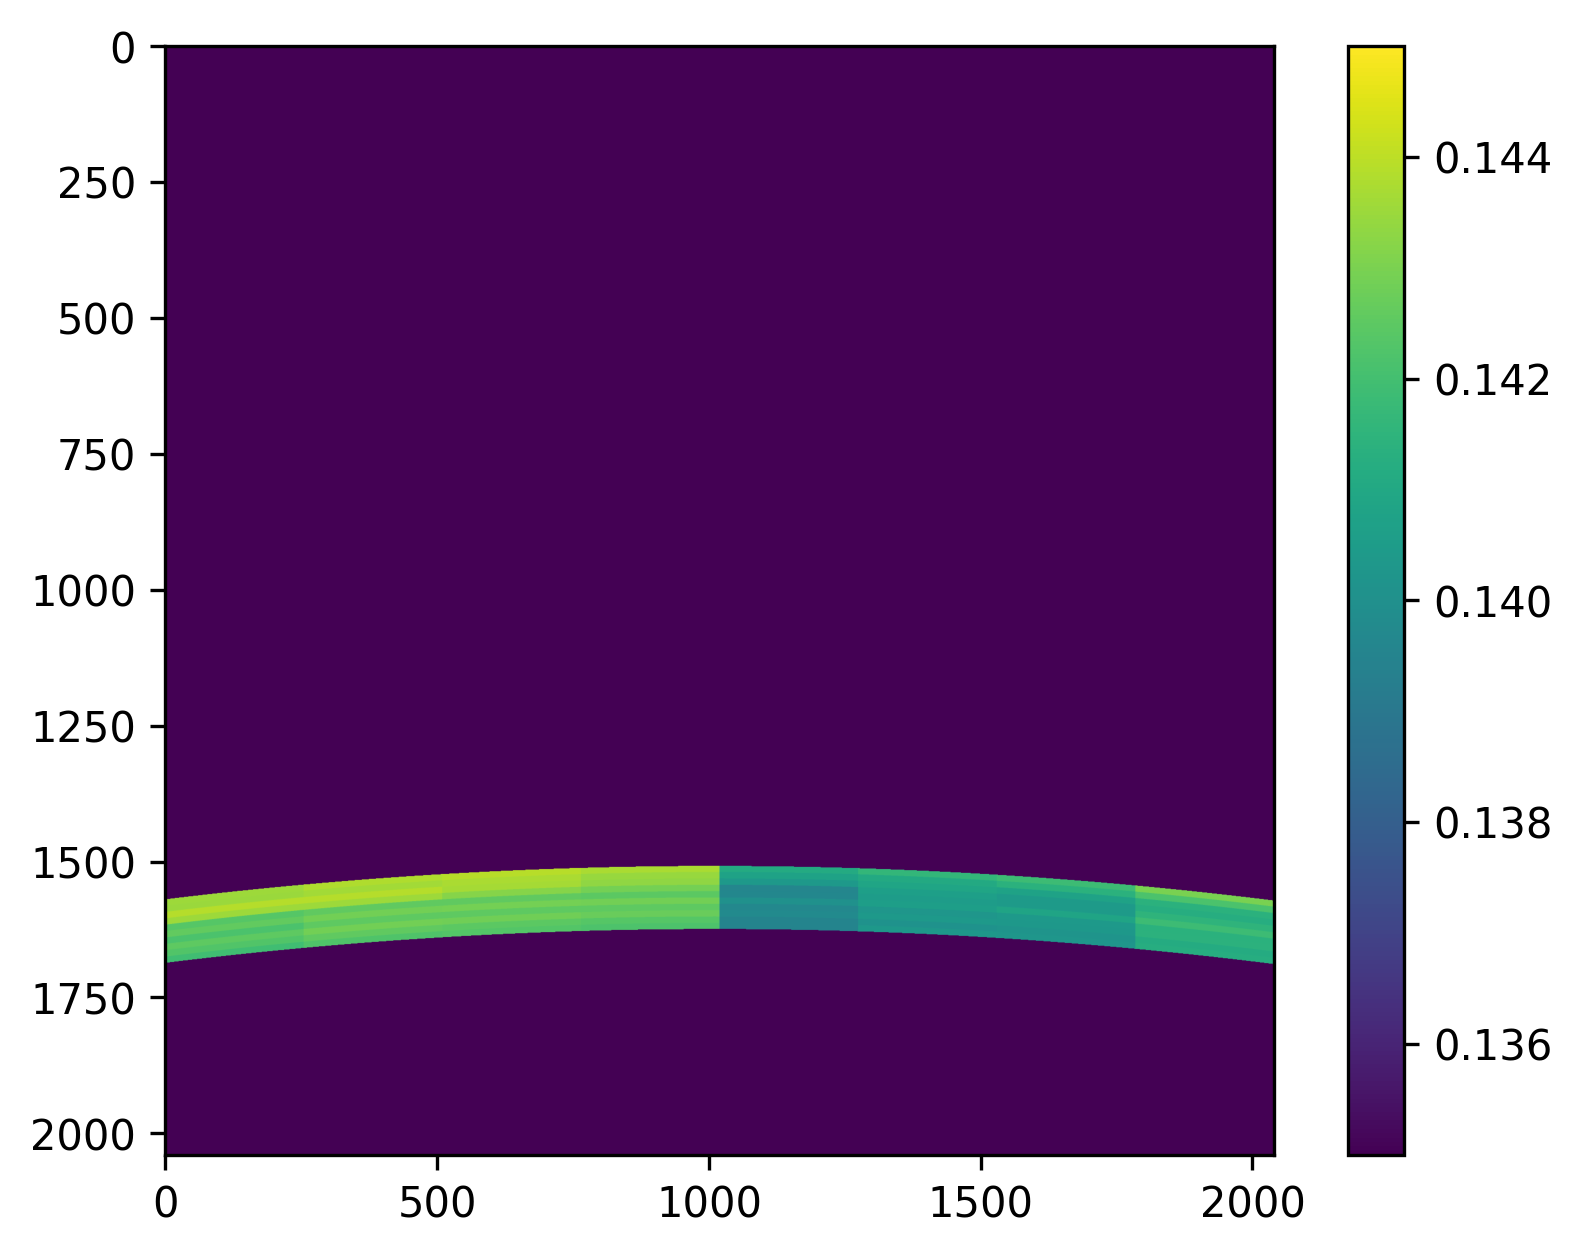

In [89]:
plt.imshow(bin2d_cv(crop_offset_map, 2), vmin=0.135, vmax=0.145)
# plt.ylim(3000, 3500)
plt.colorbar()

In [93]:
cal_path

'/mnt/md124/thomasli/selfcal/outputs/nep_det1_6p2arcsec/calibration/cal_D1_Ch4_vertical8bands.h5'

In [112]:

mm = PipelineWrapper.Mosaicker(config)
mm.load_calibration(cal_path='/mnt/md124/thomasli/selfcal/outputs/nep_det1_6p2arcsec/calibration/cal_D1_Ch4_vertical4bands.h5')
# partial_make_offset_map = partial(make_spherex_offset_map, chunk_valid_mask=chunk_valid_mask, lvf_params=lvf_params)
sc_sigma = 1.0
maps = mm.make_mosaic(
    apply_mask=True, 
    apply_weight=True, 
    chunk_map=chunk_map1, 
    det_valid_mask=det_valid_mask, 
    max_workers=40,
    make_std_map=True, 
    apply_sigma_clipping=True,  
    sigma=sc_sigma,
    ignore_list=[21],
    oversample_factor=OVERSAMPLE_FACTOR,
    det_offset_func=None,#partial_make_offset_map,
    cache_batch_size=20,
    coadd_batch_size=100,
    cache_dir='/home/thomasli/spherex/selfcal/cache',
    cache_intermediate=True,
    det_aux=None
)

    # wav_mean, wav_std = wav_coadd(det_BC, det_BW, mean_map=maps['mean_map']['data'], std_map=maps['std_map']['data'], 
    #                               reproj_list=mm.reproj_list, cache_list=mm.cached_list, ref_shape=maps['mean_map']['data'].shape, 
    #                               sigma=sc_sigma, batch_size=40, max_workers=40)    

    # wav_mean_maps = {'data': wav_mean, 'unit': 'um'}
    # wav_std_maps = {'data': wav_std, 'unit': 'um'}
    # mm.append_maps({'wav_mean_map': wav_mean_maps, 'wav_std_map': wav_std_maps})

mm.save_mosaic(mos_file=f'mosaic{FILE_PREFIX}_D{DETECTOR}_Ch{"-".join(map(str, ch))}{FILE_SUFFIX}.fits', overwrite=True)

    # # Clear memory
    # del mm, maps
    # gc.collect()
    # t1 = time.time()
    # print(f"Finished channel {ch} for detector {DETECTOR} in {t1 - t0:.2f} seconds")


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4412/4412 [00:00<00:00, 653919.55it/s]

Loading reference frame from: /mnt/md124/thomasli/selfcal/outputs/nep_det1_6p2arcsec/ref.fits
Calibration loaded from /mnt/md124/thomasli/selfcal/outputs/nep_det1_6p2arcsec/calibration/cal_D1_Ch4_vertical4bands.h5
Caching intermediate computations...
Processing 4412 files in 221 batches...


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 221/221 [04:11<00:00,  1.14s/it]


Cache computation finished in 253.75 seconds.
Computing mean map...
Processing 4412 files in 45 batches...


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 45/45 [01:31<00:00,  2.02s/it]


...

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 45/45 [01:33<00:00,  2.07s/it]


Std map computation finished in 96.97 seconds.
Computing sigma-clipped mean map...
Processing 4412 files in 45 batches...


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 45/45 [01:35<00:00,  2.13s/it]


Sigma-clipped mean map computation finished in 99.64 seconds.
Mosaic saved to /mnt/md124/thomasli/selfcal/outputs/nep_det1_6p2arcsec/mosaic/mosaic_D1_Ch4_vertical4bands.fits


'/mnt/md124/thomasli/selfcal/outputs/nep_det1_6p2arcsec/mosaic/mosaic_D1_Ch4_vertical4bands.fits'

In [113]:
mosaic = mm.maps['mean_map']['data']

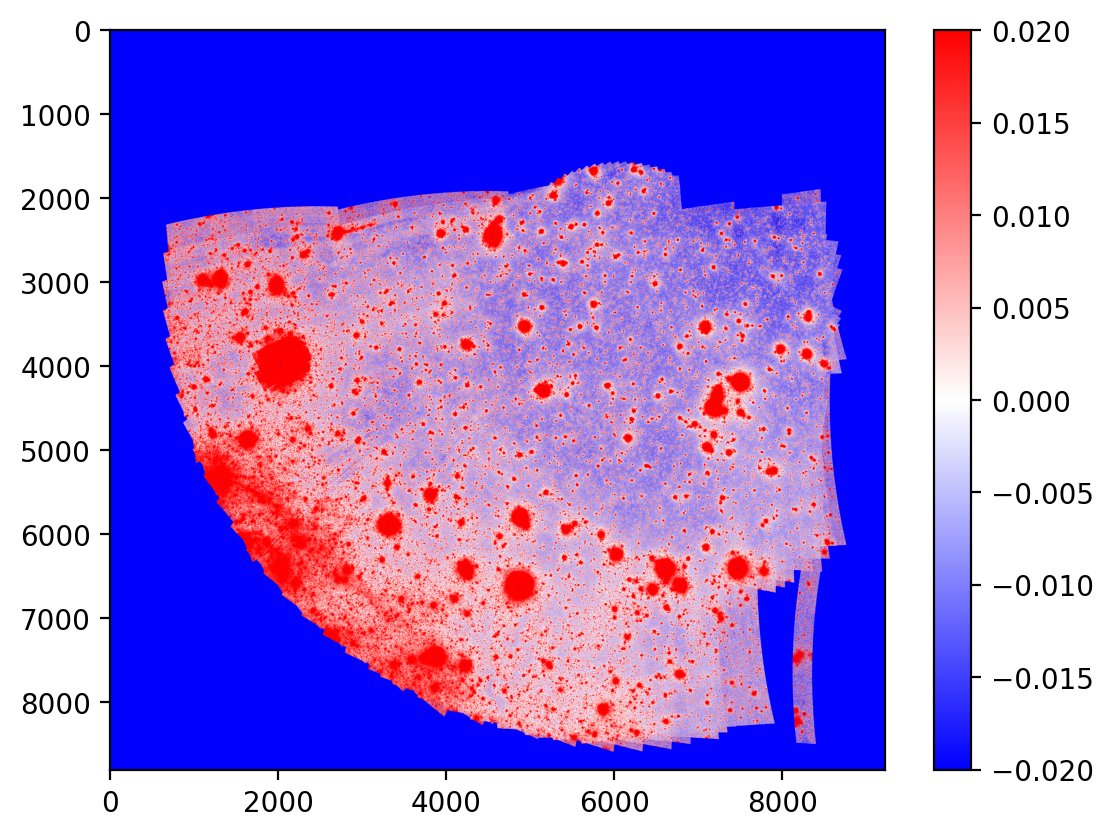

In [122]:
plt.imshow(mosaic-np.nanmedian(mosaic[np.nonzero(mosaic)]), vmin=-0.02, vmax=0.02, cmap='bwr')
plt.colorbar()

In [111]:
len(np.unique(chunk_map1))

688